In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
#Download the Fashion MNIST dataset from Zalando
dataset, metadata = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

In [3]:
#Print the metadata to see what the dataset contains
metadata

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\fotop\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [4]:
#Get the training (60k) and test (10k) data in separate variables
training_data, test_data = dataset['train'], dataset['test']

In [5]:
#Labels of the 10 possible categories
class_names = metadata.features['label'].names

In [6]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
#Normalization function for the data (Convert from 0-255 to 0-1)
#This makes the network learn better and faster
def normalize(images, labels):
  images = tf.cast(images, tf.float32)
  images /= 255 #Here it's converted from 0-255 to 0-1
  return images, labels

#Normalize the training and test data with the function we made
training_data = training_data.map(normalize)
test_data = test_data.map(normalize)

#Add to cache (use memory instead of disk for faster training)
training_data = training_data.cache()
test_data = test_data.cache()

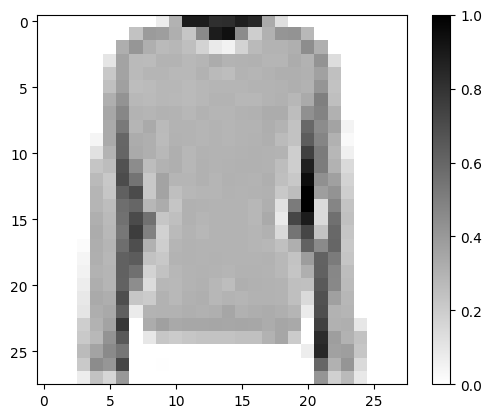

In [8]:
#Show an image from the test data, for now let's show the first one
for image, label in training_data.take(1):
  break
image = image.numpy().reshape((28,28)) #Reshape, tensor stuff, we'll see it later

import matplotlib.pyplot as plt

#Plot
plt.figure()
plt.imshow(image, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

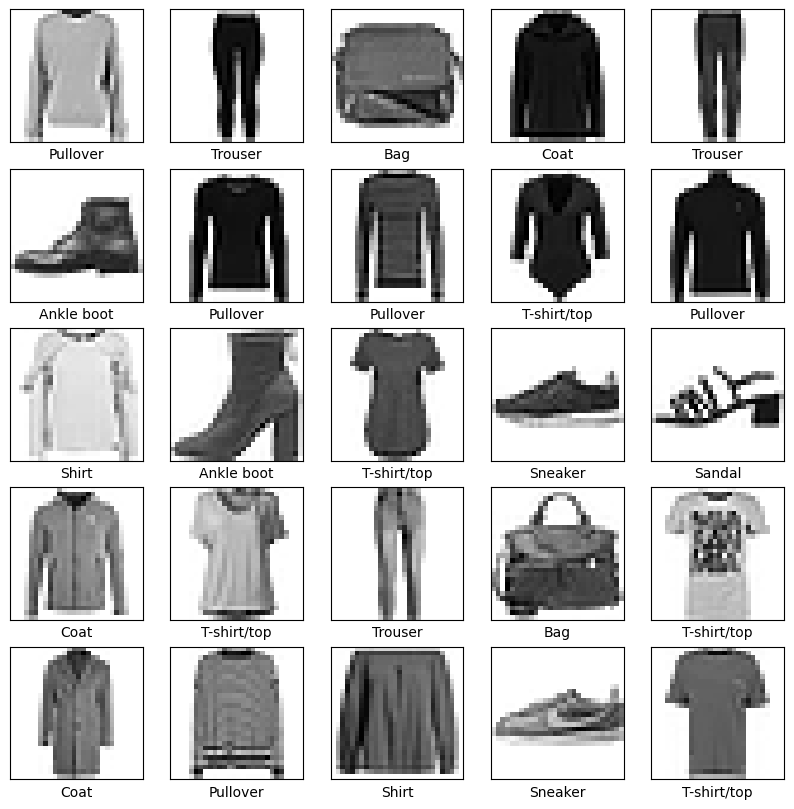

In [9]:
#Plot more
plt.figure(figsize=(10,10))
for i, (image, label) in enumerate(training_data.take(25)):
  image = image.numpy().reshape((28,28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(image, cmap=plt.cm.binary)
  plt.xlabel(class_names[label])
plt.show()

In [10]:
#Create the model
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28,1)), #1 - black and white
  tf.keras.layers.Dense(50, activation=tf.nn.relu),
  tf.keras.layers.Dense(50, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax) #For classification networks
])

C:\Users\fotop\PycharmProjects\DenseNeuralNetworkZalando\.venv1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
#Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [12]:
#Number of training and test examples (60k and 10k)
num_train_examples = metadata.splits["train"].num_examples
num_test_examples = metadata.splits["test"].num_examples

In [13]:
print(num_train_examples)
print(num_test_examples)

60000
10000


In [14]:
#Batch processing allows for more efficient training with large amounts of data
BATCH_SIZE = 32

#Shuffle and repeat ensure that the data is randomly mixed so the network
#doesn't learn the order of the items
training_data = training_data.repeat().shuffle(num_train_examples).batch(BATCH_SIZE)
test_data = test_data.batch(BATCH_SIZE)

In [15]:
import math

#Train the model
history = model.fit(training_data, epochs=15, steps_per_epoch= math.ceil(num_train_examples/BATCH_SIZE))

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 990us/step - accuracy: 0.8172 - loss: 0.5215
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 985us/step - accuracy: 0.8581 - loss: 0.3945
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.8731 - loss: 0.3539
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8784 - loss: 0.3299
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step - accuracy: 0.8872 - loss: 0.3096
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8917 - loss: 0.2939
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8925 - loss: 0.2876
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 996us/step - accuracy: 0.8969 - loss: 0.2772
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8995 - loss: 0.2707
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.9046 - loss: 0.2583
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9044 - loss: 0.2554
Epoch 12/15
1875/1

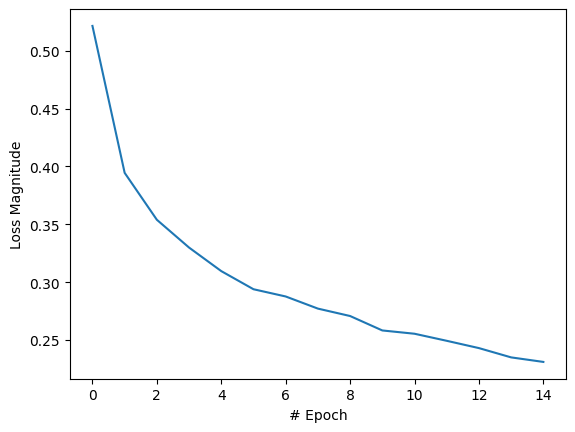

In [16]:
#View the loss function
plt.xlabel("# Epoch")
plt.ylabel("Loss Magnitude")
plt.plot(history.history["loss"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


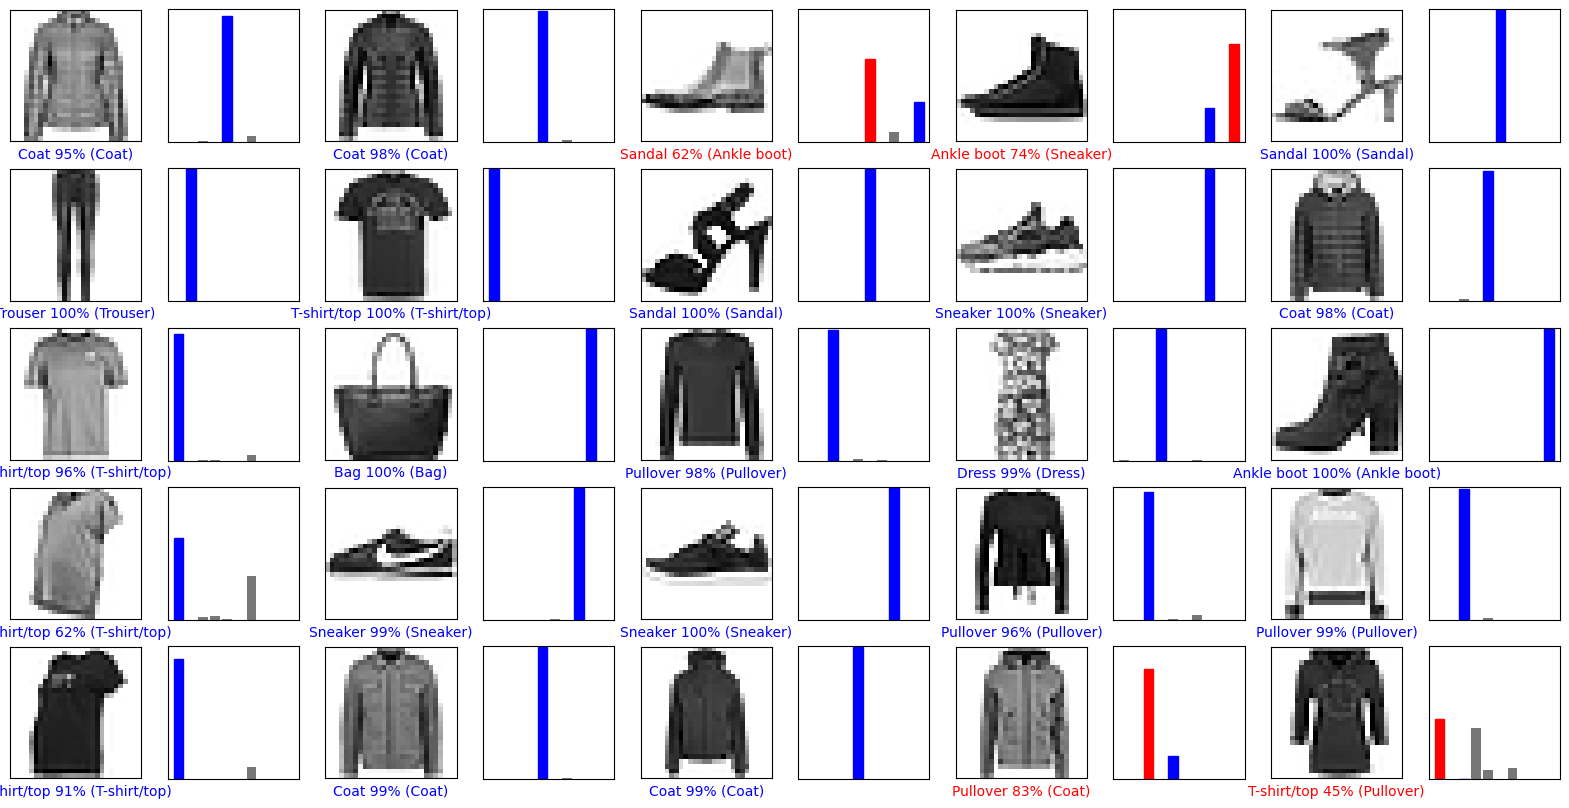

In [19]:
#Plot a grid with several predictions, and mark if they were correct (blue) or incorrect (red)
import numpy as np

for test_images, test_labels in test_data.take(1):
  test_images = test_images.numpy()
  test_labels = test_labels.numpy()
  predictions = model.predict(test_images)

def plot_image(i, predictions_array, true_labels, images):
  predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

rows = 5
cols = 5
num_images = rows*cols
plt.figure(figsize=(2*2*cols, 2*rows))
for i in range(num_images):
  plt.subplot(rows, 2*cols, 2*i+1)
  plot_image(i, predictions, test_labels, test_images)
  plt.subplot(rows, 2*cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)

In [18]:
#Test a single image
image = test_images[4] #Since the test_images variable only contains what was assigned in the previous block
image = np.array([image])
prediction = model.predict(image)

print("Prediction: " + class_names[np.argmax(prediction[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: Sandal
